# 01. Data Simulation: Primeflix 1M Subscriber Panel

This notebook generates a 78-week panel dataset representing 1,000,000 Primeflix subscribers to evaluate the causal effect of a niche competitor launch (Week 53) using a Difference-in-Differences framework.

### **Panel Design**
* **Total Base**: 1,000,000 subscribers
* **Treated Cohort**: Horror Core Viewers ($N = 80,000$, $\ge 70\%$ horror watch share)
* **Control Cohort**: Thriller Core Viewers ($N = 100,000$, $\ge 70\%$ thriller watch share)
* **Timeline**: 78 Weeks (Pre-launch: Weeks 1–52 | Post-launch: Weeks 53–78)

### **Dynamic Treatment Mechanics**
Rather than assuming an unrealistic step-function jump, the treated cohort experiences dynamic post-launch mechanics:
1. **Pre-Launch (Weeks 1–52)**: $1.0\times$ baseline churn (Parallel trends).
2. **Trial & Peak Shock (Weeks 53–60)**: Linear scale-up reaching a peak of **$1.35\times$** baseline churn at Week 60 (+0.28 percentage points).
3. **Novelty Decay & Settlement (Weeks 61–78)**: Exponential decay settling down to a long-term equilibrium of **$1.15\times$** baseline churn (+0.12 percentage points).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Set seed for exact scientific reproducibility
np.random.seed(42)

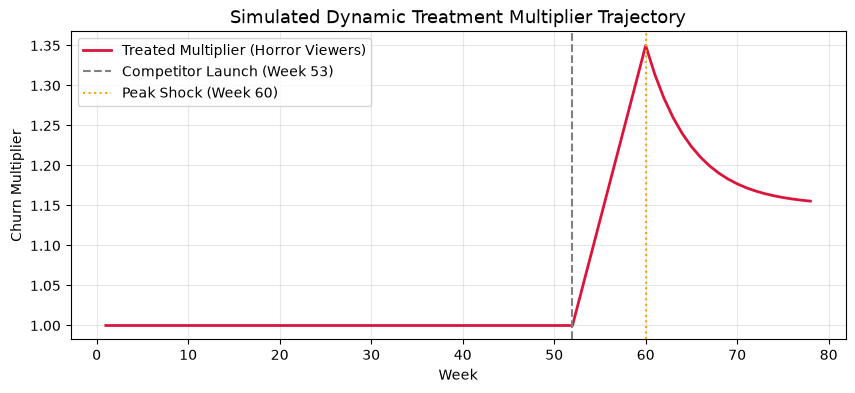

In [2]:
def calculate_dynamic_multiplier(week: int) -> float:
    """
    Calculates the weekly post-launch churn multiplier for the treated group.
    - Weeks 1–52: 1.0x (Pre-period baseline)
    - Weeks 53–60: Linear ramp-up from 1.0x to 1.35x peak
    - Weeks 61–78: Exponential decay settling down toward 1.15x
    """
    if week <= 52:
        return 1.0
    elif week <= 60:
        progress = (week - 52) / (60 - 52)
        return 1.0 + (0.35 * progress)
    else:
        weeks_post_peak = week - 60
        return 1.15 + (1.35 - 1.15) * np.exp(-0.20 * weeks_post_peak)

# Visualize simulated trajectory
weeks = np.arange(1, 79)
multipliers = [calculate_dynamic_multiplier(w) for w in weeks]

plt.figure(figsize=(10, 4))
plt.plot(weeks, multipliers, color='crimson', linewidth=2, label='Treated Multiplier (Horror Viewers)')
plt.axvline(x=52, color='gray', linestyle='--', label='Competitor Launch (Week 53)')
plt.axvline(x=60, color='orange', linestyle=':', label='Peak Shock (Week 60)')
plt.title('Simulated Dynamic Treatment Multiplier Trajectory', fontsize=13)
plt.xlabel('Week')
plt.ylabel('Churn Multiplier')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../results/dynamic_multiplier_trajectory.png', dpi=300, bbox_inches='tight')
plt.show()


In [3]:
def generate_causal_panel(
    n_total: int = 1000000,
    n_horror: int = 80000,
    n_thriller: int = 100000,
    n_weeks: int = 78,
    base_weekly_churn: float = 0.008
) -> pd.DataFrame:
    """Generates 1M subscriber panel with dynamic churn trajectory."""
    
    cust_ids = np.arange(1, n_total + 1)
    shuffled = np.random.permutation(cust_ids)
    horror_ids = set(shuffled[:n_horror])
    thriller_ids = set(shuffled[n_horror:n_horror + n_thriller])
    
    # Isolate analytical cohorts (Horror & Thriller)
    did_cohort_df = pd.DataFrame({
        'customer_id': list(horror_ids) + list(thriller_ids),
        'genre_group': ['Horror'] * n_horror + ['Thriller'] * n_thriller,
        'treated': [1] * n_horror + [0] * n_thriller
    })
    
    records = []
    weekly_shocks = np.random.normal(0, 0.0003, size=n_weeks)
    
    for week in range(1, n_weeks + 1):
        mult = calculate_dynamic_multiplier(week)
        base_p = base_weekly_churn + weekly_shocks[week - 1]
        
        # Apply dynamic multiplier strictly to treated group post-launch
        churn_probs = np.where(
            did_cohort_df['treated'] == 1,
            base_p * mult,
            base_p
        )
        churn_probs = np.clip(churn_probs, 0, 1)
        
        week_df = did_cohort_df.copy()
        week_df['week'] = week
        week_df['post_launch'] = 1 if week > 52 else 0
        week_df['churned'] = np.random.binomial(1, churn_probs)
        records.append(week_df)
        
    return pd.concat(records, ignore_index=True)

In [4]:
os.makedirs('../data/processed', exist_ok=True)

print("Simulating 1,000,000 subscriber base and compiling 78-week panel...")
df_panel = generate_causal_panel()

# Calculate weekly mean rates and sample weights for Weighted Least Squares (WLS)
weekly_agg = df_panel.groupby(['genre_group', 'week', 'treated', 'post_launch']).agg(
    churned=('churned', 'mean'),
    sub_count=('churned', 'count')
).reset_index()

weekly_agg.to_csv('../data/processed/did_weekly_aggregated.csv', index=False)
print("Data simulation complete. Aggregated weekly dataset saved to ../data/processed/did_weekly_aggregated.csv")

Simulating 1,000,000 subscriber base and compiling 78-week panel...
Data simulation complete. Aggregated weekly dataset saved to ../data/processed/did_weekly_aggregated.csv
